In [1]:
# =============================================================================
# NOTEBOOK 02: STAGE 1 — AUGMENTATION EXPERIMENTS (ResNet50)
# =============================================================================
# Runs Exp 0, 1, 2 with ResNet50 held constant.
# Includes full evaluation (confusion matrix, per-class metrics, AUC) after each.
# =============================================================================


In [2]:
from utils import *

print("Classes:", CLASS_NAMES)
print("GPU:", tf.config.list_physical_devices('GPU'))

Classes: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
GPU: []


In [3]:
# Compute class weights
class_weights = compute_class_weights()

# Load raw (unbatched) datasets
raw_train = load_base_dataset(TRAIN_DIR, shuffle=True)
raw_val   = load_base_dataset(VAL_DIR, shuffle=False)
raw_test  = load_base_dataset(TEST_DIR, shuffle=False)

# Val and Test — always no augmentation
val_ds  = build_dataset_no_aug(raw_val, shuffle=False)
test_ds = build_dataset_no_aug(raw_test, shuffle=False)

print("Datasets loaded.")

Found 8012 files belonging to 7 classes.
Found 1001 files belonging to 7 classes.
Found 1002 files belonging to 7 classes.
Datasets loaded.



############################################################
  EXPERIMENT: exp0_resnet50_no_aug
############################################################



wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /Users/emiryscn/.netrc.
wandb: Currently logged in as: emiryscn (emiryscn-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


ResNet50 built. Base layers: 175, Total params: 24,114,055

--- PHASE A: Feature Extraction (Frozen Base) ---
Epoch 1/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 118s 457ms/step - accuracy: 0.4656 - loss: 1.6878 - val_accuracy: 0.6084 - val_loss: 1.0131 - learning_rate: 0.0010
Epoch 2/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 119s 470ms/step - accuracy: 0.5442 - loss: 1.1854 - val_accuracy: 0.6154 - val_loss: 0.9263 - learning_rate: 0.0010
Epoch 3/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 120s 473ms/step - accuracy: 0.5645 - loss: 1.0975 - val_accuracy: 0.5584 - val_loss: 1.1544 - learning_rate: 0.0010
Epoch 4/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 120s 476ms/step - accuracy: 0.6025 - loss: 0.9915 - val_accuracy: 0.6394 - val_loss: 0.8682 - learning_rate: 0.0010
Epoch 5/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 121s 479ms/step - accuracy: 0.6239 - loss: 0.8911 - val_accuracy: 0.6214 - val_loss: 0.8881 - learning_rate: 0.0010
Epoch 6/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 122s 484ms/step - accuracy: 0.6110 - loss: 0.9029 - val_accuracy: 0.65

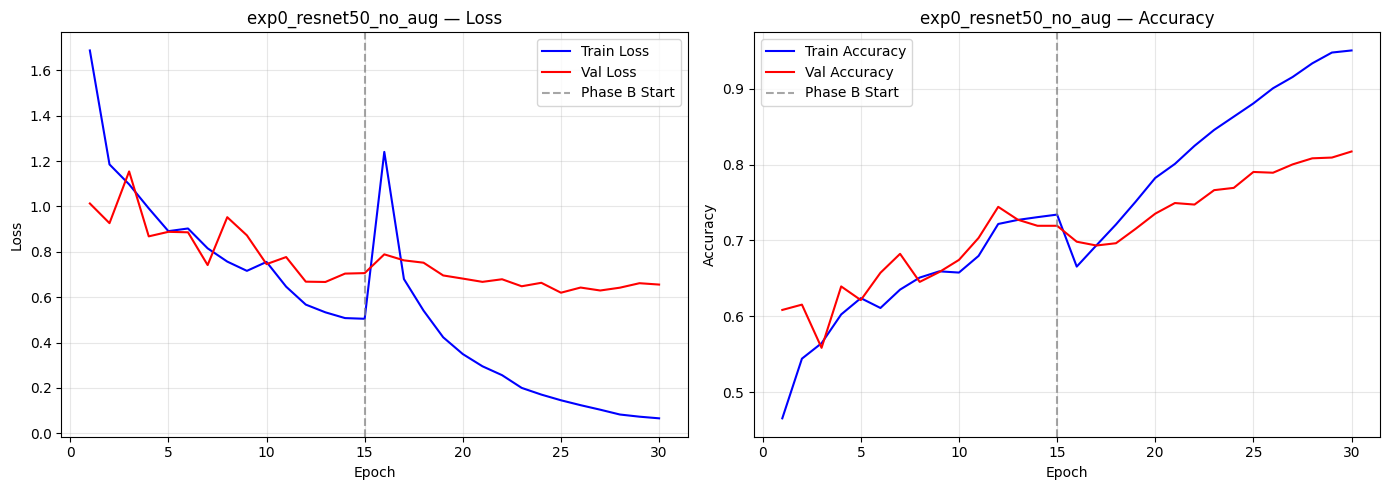


Model saved to: /Users/emiryscn/repos/multi-class-skin-lesion-detection/models/exp0_resnet50_no_aug_final.keras

  EVALUATION: exp0_resnet50_no_aug

              precision    recall  f1-score   support

       akiec     0.6667    0.6061    0.6349        33
         bcc     0.6296    0.6667    0.6476        51
         bkl     0.6083    0.6636    0.6348       110
          df     0.4000    0.6667    0.5000        12
         mel     0.5135    0.6847    0.5869       111
          nv     0.9331    0.8525    0.8910       671
        vasc     0.7059    0.8571    0.7742        14

    accuracy                         0.7934      1002
   macro avg     0.6367    0.7139    0.6671      1002
weighted avg     0.8172    0.7934    0.8020      1002



2026-03-13 01:37:21.890925: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


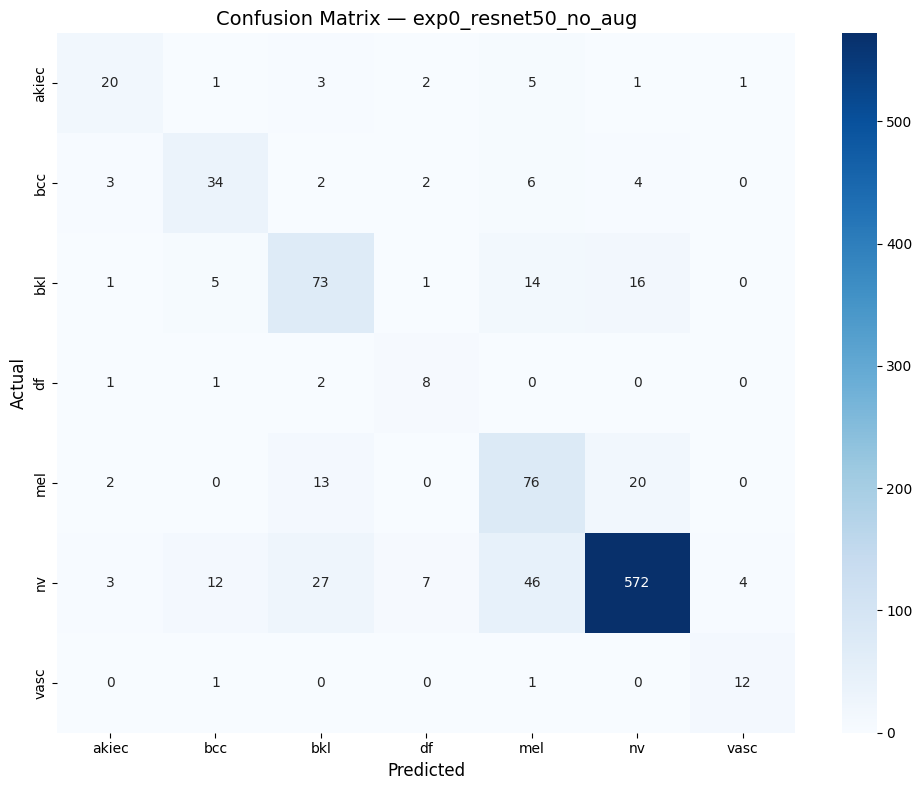

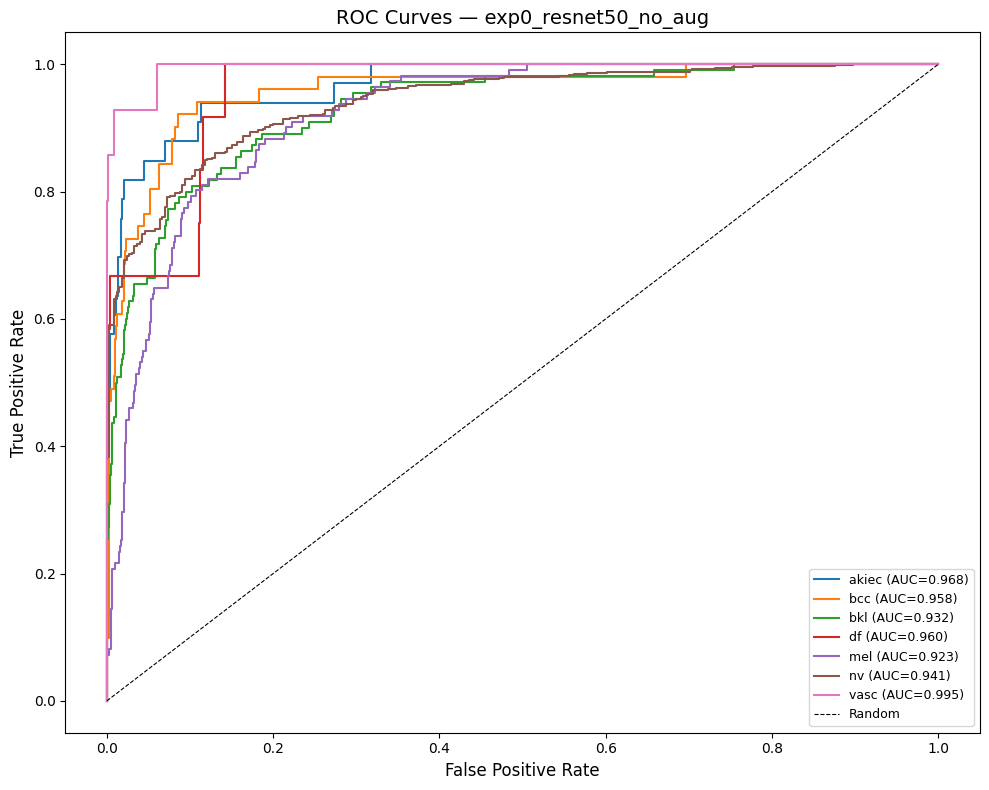


--- KEY METRICS ---
  Overall Accuracy:  0.7934
  Macro F1-Score:    0.6671
  Macro Recall:      0.7139
  Mean AUC-ROC:      0.9538
  Melanoma Recall:   0.6847  ← CRITICAL
  Melanoma F1:       0.5869

  Results saved to: /Users/emiryscn/repos/multi-class-skin-lesion-detection/results/exp0_resnet50_no_aug_*


epoch/accuracy,▁▂▂▃▃▃▃▄▄▄▄▅▅▅▅▄▄▅▅▆▆▆▆▇▇▇▇███
epoch/epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
epoch/learning_rate,█████████▄▄▄▄▄▄▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/loss,█▆▅▅▅▅▄▄▄▄▄▃▃▃▃▆▄▃▃▂▂▂▂▁▁▁▁▁▁▁
epoch/val_accuracy,▂▃▁▃▃▄▄▃▄▄▅▆▆▅▅▅▅▅▅▆▆▆▇▇▇▇████
epoch/val_loss,▆▅█▄▅▄▃▅▄▃▃▂▂▂▂▃▃▃▂▂▂▂▁▂▁▁▁▁▂▁
test/accuracy,▁
test/macro_f1,▁
test/macro_recall,▁
test/mean_auc,▁
+2,...



  exp0_resnet50_no_aug COMPLETE



In [4]:
# EXPERIMENT 0: ResNet50 + No Augmentation
# =============================================================================
# Goal: Establish the bias floor. See how class imbalance affects the model.

train_ds_exp0 = build_dataset_no_aug(raw_train, shuffle=True)

model_exp0, summary_exp0 = run_experiment(
    experiment_name="exp0_resnet50_no_aug",
    train_ds=train_ds_exp0,
    val_ds=val_ds,
    test_ds=test_ds,
    build_model_fn=build_resnet50,
    class_weights=class_weights,
    use_class_weights=True
)


############################################################
  EXPERIMENT: exp1_resnet50_basic_aug
############################################################



ResNet50 built. Base layers: 175, Total params: 24,114,055

--- PHASE A: Feature Extraction (Frozen Base) ---
Epoch 1/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 128s 500ms/step - accuracy: 0.4822 - loss: 1.5781 - val_accuracy: 0.6494 - val_loss: 0.9751 - learning_rate: 0.0010
Epoch 2/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 127s 501ms/step - accuracy: 0.5637 - loss: 1.1914 - val_accuracy: 0.5245 - val_loss: 1.1375 - learning_rate: 0.0010
Epoch 3/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 128s 504ms/step - accuracy: 0.5735 - loss: 1.0935 - val_accuracy: 0.6434 - val_loss: 0.8637 - learning_rate: 0.0010
Epoch 4/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 127s 501ms/step - accuracy: 0.5960 - loss: 1.0297 - val_accuracy: 0.6244 - val_loss: 1.0102 - learning_rate: 0.0010
Epoch 5/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 127s 503ms/step - accuracy: 0.6172 - loss: 0.9605 - val_accuracy: 0.6134 - val_loss: 1.0029 - learning_rate: 0.0010
Epoch 6/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 127s 502ms/step - accuracy: 0.6169 - loss: 0.9025 - val_accuracy: 0.67

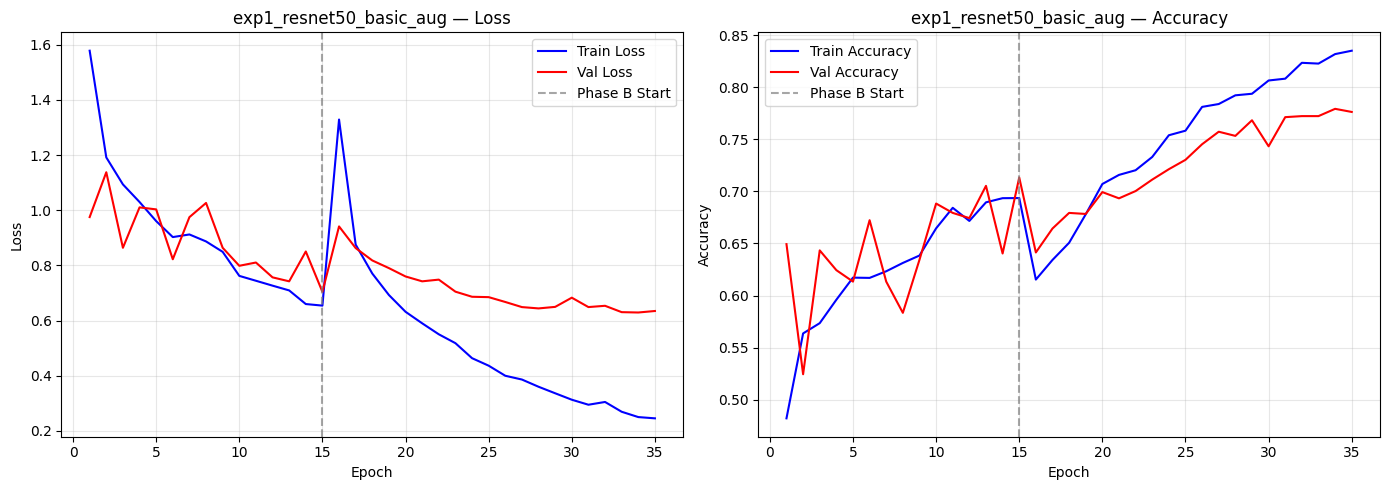


Model saved to: /Users/emiryscn/repos/multi-class-skin-lesion-detection/models/exp1_resnet50_basic_aug_final.keras

  EVALUATION: exp1_resnet50_basic_aug

              precision    recall  f1-score   support

       akiec     0.7692    0.6061    0.6780        33
         bcc     0.7317    0.5882    0.6522        51
         bkl     0.5148    0.7909    0.6237       110
          df     0.4737    0.7500    0.5806        12
         mel     0.4684    0.8018    0.5914       111
          nv     0.9705    0.7839    0.8673       671
        vasc     0.8000    0.8571    0.8276        14

    accuracy                         0.7715      1002
   macro avg     0.6755    0.7397    0.6887      1002
weighted avg     0.8377    0.7715    0.7888      1002



2026-03-13 03:25:23.041108: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


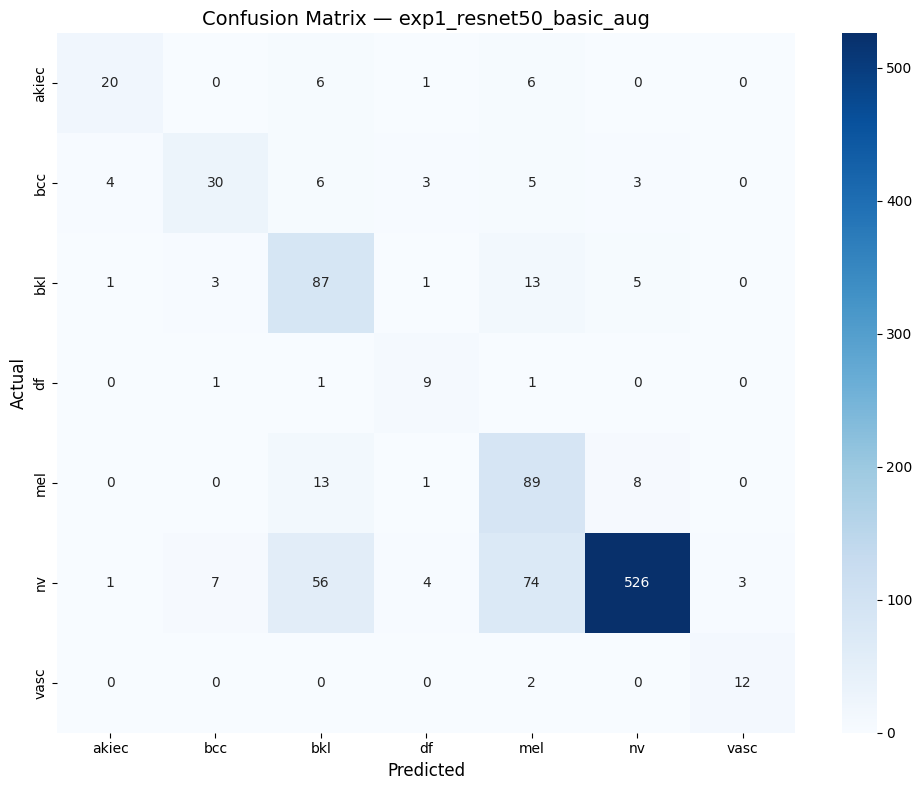

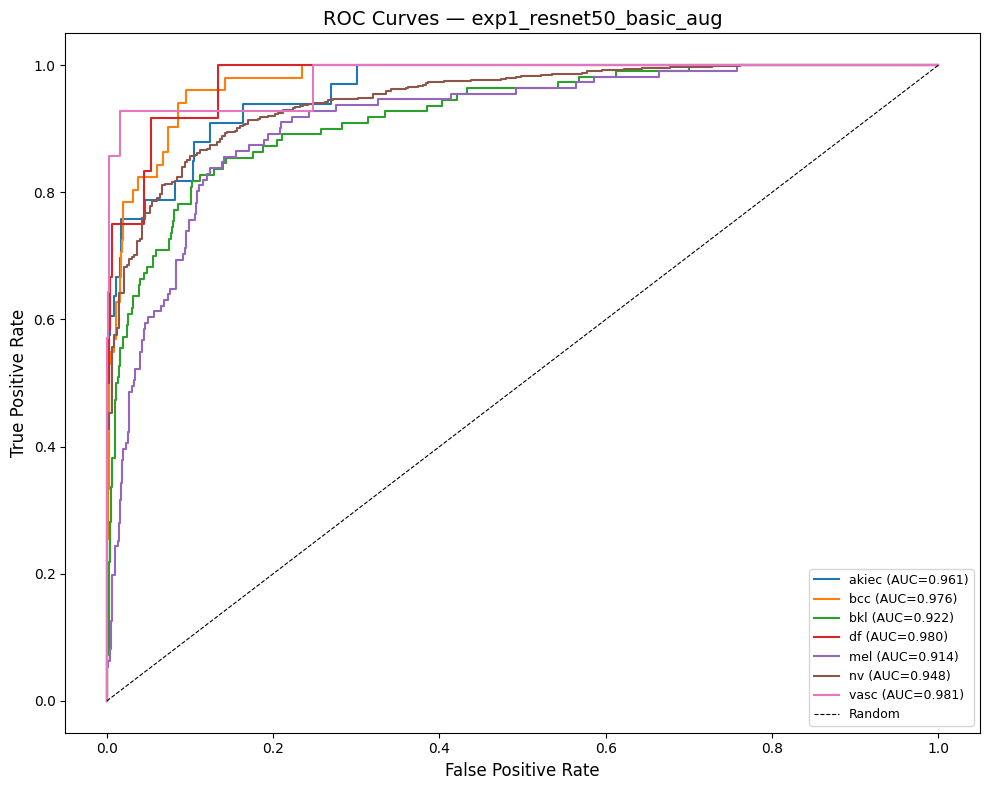


--- KEY METRICS ---
  Overall Accuracy:  0.7715
  Macro F1-Score:    0.6887
  Macro Recall:      0.7397
  Mean AUC-ROC:      0.9545
  Melanoma Recall:   0.8018  ← CRITICAL
  Melanoma F1:       0.5914

  Results saved to: /Users/emiryscn/repos/multi-class-skin-lesion-detection/results/exp1_resnet50_basic_aug_*


epoch/accuracy,▁▃▃▃▄▄▄▄▄▅▅▅▅▅▅▄▄▄▅▅▆▆▆▆▆▇▇▇▇▇▇████
epoch/epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
epoch/learning_rate,████████▄▄▄▄▄▄▄▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/loss,█▆▅▅▅▄▅▄▄▄▄▄▃▃▃▇▄▄▃▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁
epoch/val_accuracy,▄▁▄▄▃▅▃▃▄▆▅▅▆▄▆▄▅▅▅▆▆▆▆▆▇▇▇▇█▇█████
epoch/val_loss,▆█▄▆▆▄▆▆▄▃▃▃▃▄▂▅▄▄▃▃▃▃▂▂▂▂▁▁▁▂▁▁▁▁▁
test/accuracy,▁
test/macro_f1,▁
test/macro_recall,▁
test/mean_auc,▁
+2,...



  exp1_resnet50_basic_aug COMPLETE



In [5]:
# EXPERIMENT 1: ResNet50 + Traditional Augmentation
# =============================================================================
# Goal: See improvement from basic augmentation (flip, rotate, zoom).

train_ds_exp1 = build_dataset_traditional_aug(raw_train)

model_exp1, summary_exp1 = run_experiment(
    experiment_name="exp1_resnet50_basic_aug",
    train_ds=train_ds_exp1,
    val_ds=val_ds,
    test_ds=test_ds,
    build_model_fn=build_resnet50,
    class_weights=class_weights,
    use_class_weights=True
)



############################################################
  EXPERIMENT: exp2_resnet50_mixup_cutmix
############################################################



ResNet50 built. Base layers: 175, Total params: 24,114,055

--- PHASE A: Feature Extraction (Frozen Base) ---
Epoch 1/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 131s 508ms/step - accuracy: 0.6769 - loss: 1.0322 - val_accuracy: 0.7083 - val_loss: 0.7515 - learning_rate: 0.0010
Epoch 2/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 128s 505ms/step - accuracy: 0.7106 - loss: 0.8786 - val_accuracy: 0.7413 - val_loss: 0.7206 - learning_rate: 0.0010
Epoch 3/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 129s 510ms/step - accuracy: 0.7156 - loss: 0.8707 - val_accuracy: 0.7333 - val_loss: 0.7085 - learning_rate: 0.0010
Epoch 4/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 129s 511ms/step - accuracy: 0.7280 - loss: 0.8433 - val_accuracy: 0.7303 - val_loss: 0.6788 - learning_rate: 0.0010
Epoch 5/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 129s 509ms/step - accuracy: 0.7250 - loss: 0.8328 - val_accuracy: 0.7682 - val_loss: 0.6452 - learning_rate: 0.0010
Epoch 6/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 128s 507ms/step - accuracy: 0.7335 - loss: 0.8213 - val_accuracy: 0.75

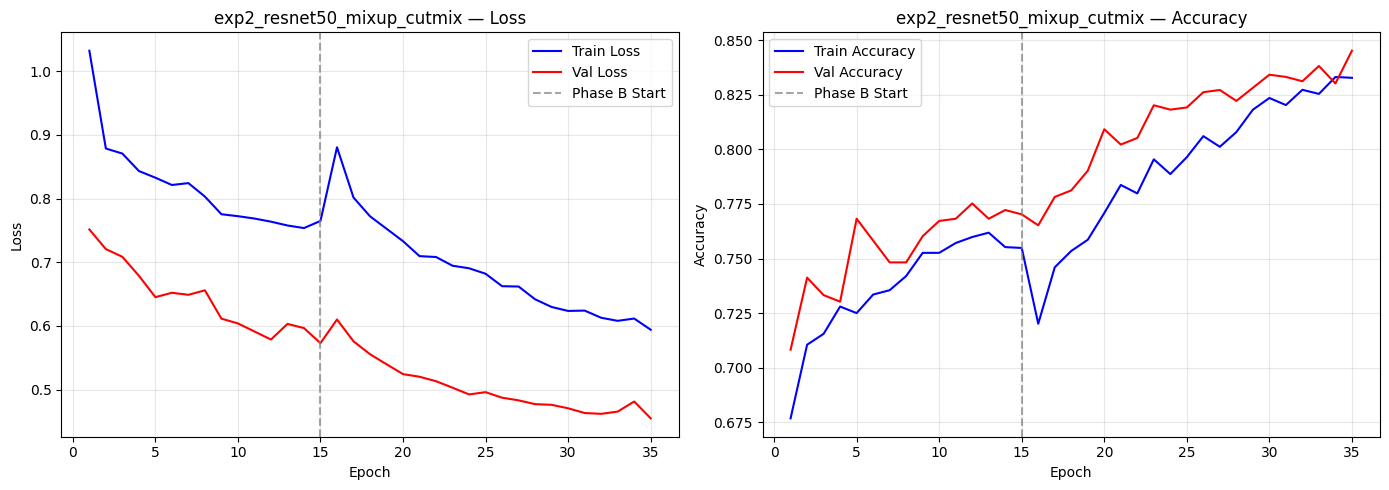


Model saved to: /Users/emiryscn/repos/multi-class-skin-lesion-detection/models/exp2_resnet50_mixup_cutmix_final.keras

  EVALUATION: exp2_resnet50_mixup_cutmix

              precision    recall  f1-score   support

       akiec     0.8095    0.5152    0.6296        33
         bcc     0.8182    0.5294    0.6429        51
         bkl     0.6343    0.7727    0.6967       110
          df     0.6667    0.5000    0.5714        12
         mel     0.6543    0.4775    0.5521       111
          nv     0.8904    0.9449    0.9168       671
        vasc     0.9167    0.7857    0.8462        14

    accuracy                         0.8313      1002
   macro avg     0.7700    0.6465    0.6937      1002
weighted avg     0.8275    0.8313    0.8237      1002



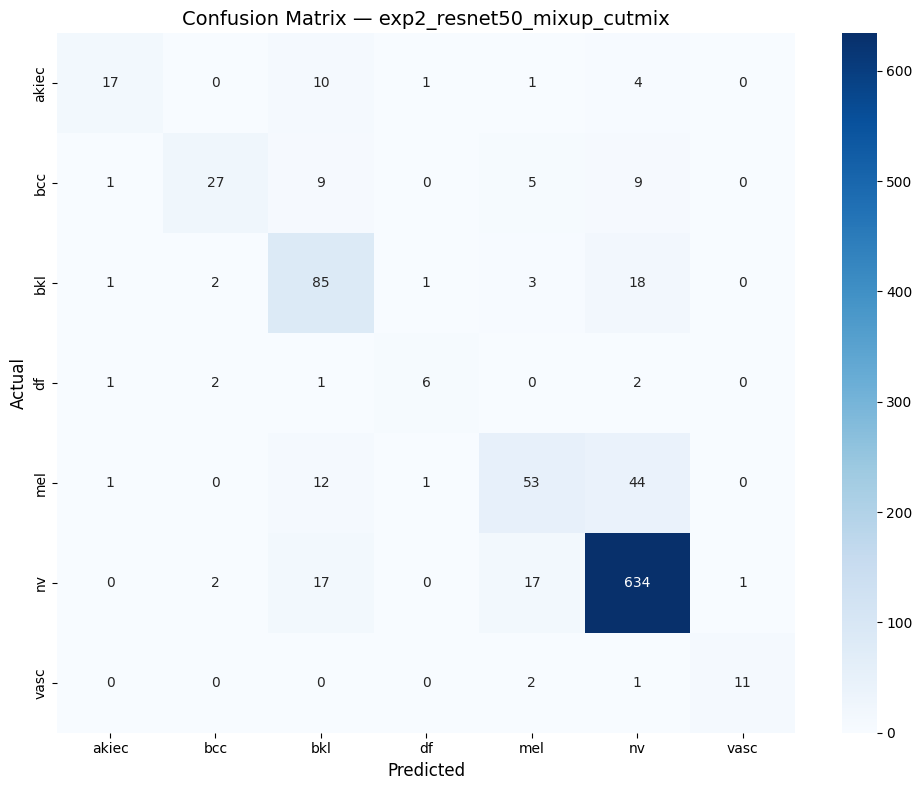

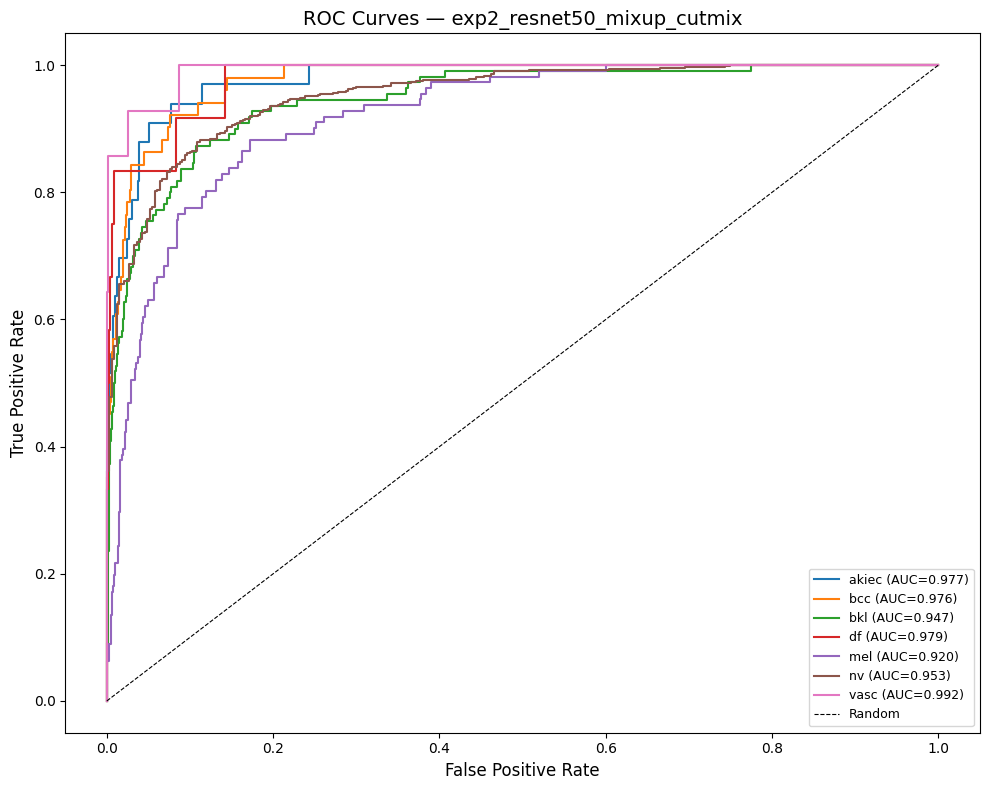


--- KEY METRICS ---
  Overall Accuracy:  0.8313
  Macro F1-Score:    0.6937
  Macro Recall:      0.6465
  Mean AUC-ROC:      0.9635
  Melanoma Recall:   0.4775  ← CRITICAL
  Melanoma F1:       0.5521

  Results saved to: /Users/emiryscn/repos/multi-class-skin-lesion-detection/results/exp2_resnet50_mixup_cutmix_*


epoch/accuracy,▁▃▃▃▃▄▄▄▄▄▅▅▅▅▄▃▄▄▅▅▆▆▆▆▆▇▇▇▇█▇████
epoch/epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
epoch/learning_rate,███████▄▄▄▄▄▄▄▄▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/loss,█▆▅▅▅▅▅▄▄▄▄▄▄▄▄▆▄▄▄▃▃▃▃▃▂▂▂▂▂▁▁▁▁▁▁
epoch/val_accuracy,▁▃▂▂▄▄▃▃▄▄▄▄▄▄▄▄▅▅▅▆▆▆▇▇▇▇▇▇▇▇▇▇█▇█
epoch/val_loss,█▇▇▆▅▆▆▆▅▅▄▄▄▄▄▅▄▃▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▂▁
test/accuracy,▁
test/macro_f1,▁
test/macro_recall,▁
test/mean_auc,▁
+2,...



  exp2_resnet50_mixup_cutmix COMPLETE



In [6]:
# EXPERIMENT 2: ResNet50 + MixUp/CutMix
# =============================================================================
# Goal: See improvement from advanced synthetic augmentation.
# class_weights=False because MixUp/CutMix produce soft labels.

train_ds_exp2 = build_dataset_mixup_cutmix(raw_train)

model_exp2, summary_exp2 = run_experiment(
    experiment_name="exp2_resnet50_mixup_cutmix",
    train_ds=train_ds_exp2,
    val_ds=val_ds,
    test_ds=test_ds,
    build_model_fn=build_resnet50,
    class_weights=class_weights,
    use_class_weights=False
)


  stage1 RESULTS COMPARISON
                Experiment Accuracy Macro F1 Macro Recall Mean AUC Mel Recall Mel F1
      exp0_resnet50_no_aug   0.7934   0.6671       0.7139   0.9538     0.6847 0.5869
   exp1_resnet50_basic_aug   0.7715   0.6887       0.7397   0.9545     0.8018 0.5914
exp2_resnet50_mixup_cutmix   0.8313   0.6937       0.6465   0.9635     0.4775 0.5521

--- Per-Class F1 Scores ---
       exp0_resnet50_no_aug  exp1_resnet50_basic_aug  exp2_resnet50_mixup_cutmix
akiec              0.634921                 0.677966                    0.629630
bcc                0.647619                 0.652174                    0.642857
bkl                0.634783                 0.623656                    0.696721
df                 0.500000                 0.580645                    0.571429
mel                0.586873                 0.591362                    0.552083
nv                 0.890966                 0.867271                    0.916847
vasc               0.774194        

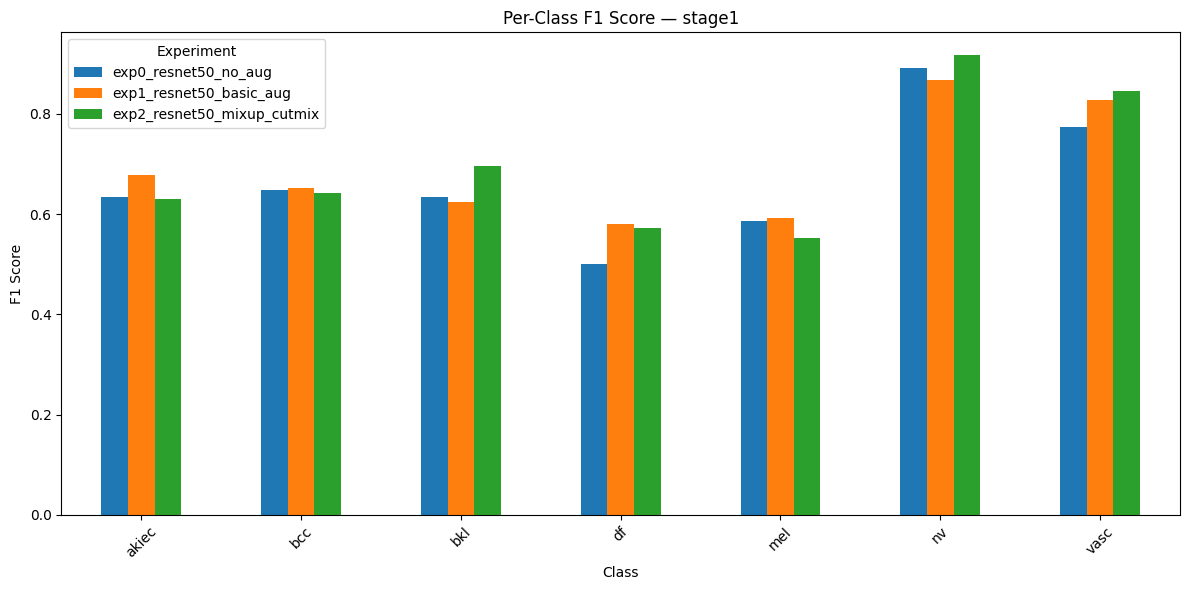


--- Per-Class Recall (Sensitivity) ---
       exp0_resnet50_no_aug  exp1_resnet50_basic_aug  exp2_resnet50_mixup_cutmix
akiec              0.606061                 0.606061                    0.515152
bcc                0.666667                 0.588235                    0.529412
bkl                0.663636                 0.790909                    0.772727
df                 0.666667                 0.750000                    0.500000
mel                0.684685                 0.801802                    0.477477
nv                 0.852459                 0.783905                    0.944858
vasc               0.857143                 0.857143                    0.785714


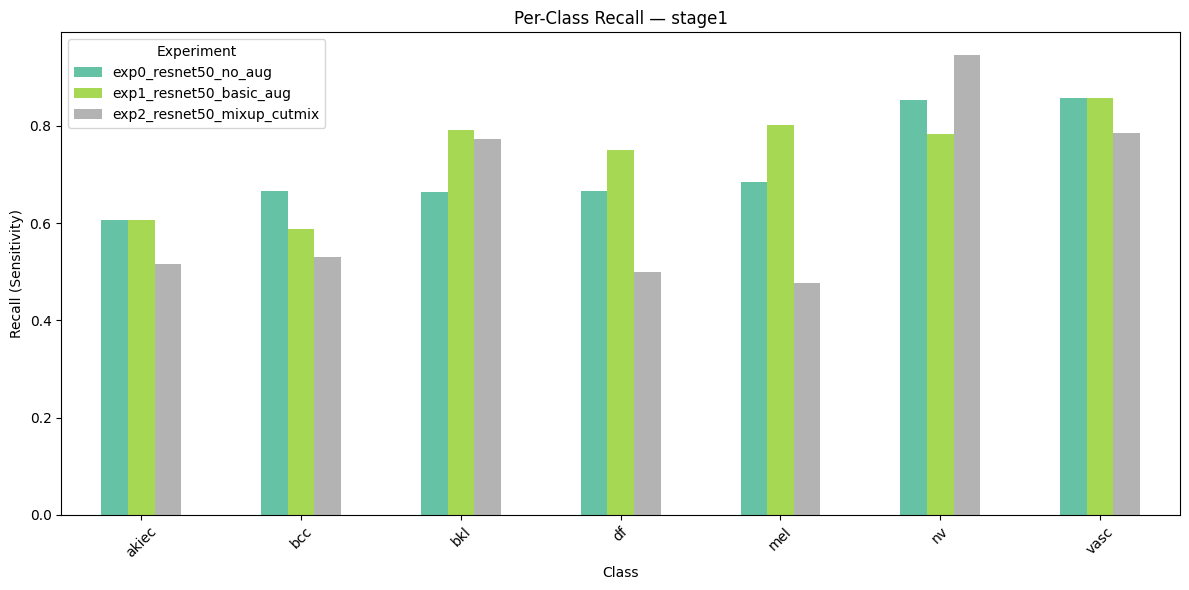

,Experiment,Accuracy,Macro F1,Macro Recall,Mean AUC,Mel Recall,Mel F1
0,exp0_resnet50_no_aug,0.7934,0.6671,0.7139,0.9538,0.6847,0.5869
1,exp1_resnet50_basic_aug,0.7715,0.6887,0.7397,0.9545,0.8018,0.5914
2,exp2_resnet50_mixup_cutmix,0.8313,0.6937,0.6465,0.9635,0.4775,0.5521


In [7]:
all_summaries = [summary_exp0, summary_exp1, summary_exp2]
compare_experiments(all_summaries, "stage1")

In [8]:
best_idx, best_exp = select_best_experiment(all_summaries)
 
# Map to dataset builder for Stage 2
exp_to_builder = {
    0: ("build_dataset_no_aug", "No Augmentation", True),
    1: ("build_dataset_traditional_aug", "Traditional Augmentation", True),
    2: ("build_dataset_mixup_cutmix", "MixUp + CutMix", False),
}
 
builder_name, strategy_name, use_cw = exp_to_builder[best_idx]
print(f"\n  → Use '{builder_name}' in Stage 2 (Notebook 03)")
print(f"  → Strategy: {strategy_name}")
print(f"  → Use class_weights: {use_cw}")
 
# Save decision for Notebook 03
with open(os.path.join(RESULTS_DIR, "stage1_best_strategy.json"), 'w') as f:
    json.dump({
        "best_experiment_index": best_idx,
        "best_experiment_name": best_exp['experiment'],
        "best_strategy": strategy_name,
        "builder_function": builder_name,
        "macro_f1": float(best_exp['macro_f1']),
        "mel_recall": float(best_exp['mel_recall']),
        "use_class_weights": use_cw
    }, f, indent=2)
 
print(f"  Decision saved to: {RESULTS_DIR}/stage1_best_strategy.json")


  BEST EXPERIMENT (by macro_f1)
  Winner:       exp2_resnet50_mixup_cutmix
  Macro F1:     0.6937
  Mel Recall:   0.4775
  Mean AUC:     0.9635

  → Use 'build_dataset_mixup_cutmix' in Stage 2 (Notebook 03)
  → Strategy: MixUp + CutMix
  → Use class_weights: False
  Decision saved to: /Users/emiryscn/repos/multi-class-skin-lesion-detection/results/stage1_best_strategy.json
